# AG-HYPOPT · Trial 27

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-six trials are recorded. Best is trial_07 (sw 0.865, h_f 4.0, h_s 3.675, cap 0.107) at 0.0803; trial_26 (sw 0.919, h_f 4.0, h_s 3.608, cap 0.163) is a very close second at 0.0807, so a second near-optimal point exists in the high-sw corner. Then trial_20 0.0821, trial_05 0.0822, trial_09 0.0839, trial_18 0.0844, trial_16 0.0850, trial_21 0.0852, trial_22 0.0853, ... up to trial_10 0.0922. All 0 diverged, gamma finite. Phase 'trials'.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_27'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (26/5 trials)
ID |     ei | params
 1 | 3.5247 | {"gamma_rel_cap": 0.23901584835436496, "h_f_scale": 1.4634682060529787, "h_s_scale": 3.606096709748633, "sigma_weight": 0.19893321718647516}
 2 | 3.3731 | {"gamma_rel_cap": 0.07227236386352308, "h_f_scale": 3.9540882991295736, "h_s_scale": 3.6063443664887145, "sigma_weight": 0.7145315177139158}
 3 | 3.7135 | {"gamma_rel_cap": 0.16362076883456098, "h_f_scale": 3.9532783064480035, "h_s_scale": 3.614158881302266, "sigma_weight": 0.3449132425611384}
 4 | 2.9330 | {"gamma_rel_cap": 0.1829889176863247, "h_f_scale": 3.5881125008588683, "h_s_scale": 3.6060714423780484, "sigma_weight": 1.0}
 5 | 1.9075 | {"gamma_rel_cap": 0.16144355505927507, "h_f_scale": 4.0, "h_s_scale": 1.9921464427569435, "sigma_weight": 0.8983618372948541}
 6 | 3.3122 | {"gamma_rel_cap": 0.4973398012701983, "h_f_scale": 3.989631433418793, "h_s_scale": 3.683366475017465, "sigma_weight": 0.8664365178290101}
 7 | 2.7362 | {"gamma_rel_cap": 0.23690623941143327, "

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

trial_07 (0.0803) and trial_26 (0.0807) are the two near-optimal points; the batch this time has no draw inside the good cap band. The top-ei draws all set caps far from ~0.1-0.2 or move sw well off.

Candidate 6 (ei 3.3122) is the least-distant draw from the optimum point: its sw (0.866) and kernels (h_f 3.990, h_s 3.683) are essentially trial_07's, and only the gamma cap is off (0.497). It therefore isolates the cap effect at the known-good sw/kernels and is the batch draw closest to the optimum, even though a large cap has consistently been unfavourable.

I choose candidate 6.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6               # candidate 6: sigma_weight 0.866, h_f_scale 3.990, h_s_scale 3.683, gamma_rel_cap 0.497 (near-optimal sw/kernels, large cap)


chosen: {'gamma_rel_cap': 0.4973398012701983, 'h_f_scale': 3.989631433418793, 'h_s_scale': 3.683366475017465, 'sigma_weight': 0.8664365178290101}
Running  1nW Trans05 ... 

μ 9.39 -> 5.86 | γ 8.5 -> 2.48 | NLL 0.25


Running  1nW Trans20 ... 

μ 17.32 -> 27.72 | γ 8.5 -> 5.43 | NLL 0.65


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 64.77 | γ 14.1 -> 14.00 | NLL 0.70


Running 3nW Trans100 ... 

μ 175.71 -> 99.31 | γ 14.1 -> 13.72 | NLL 0.66



Total: 7.7 min


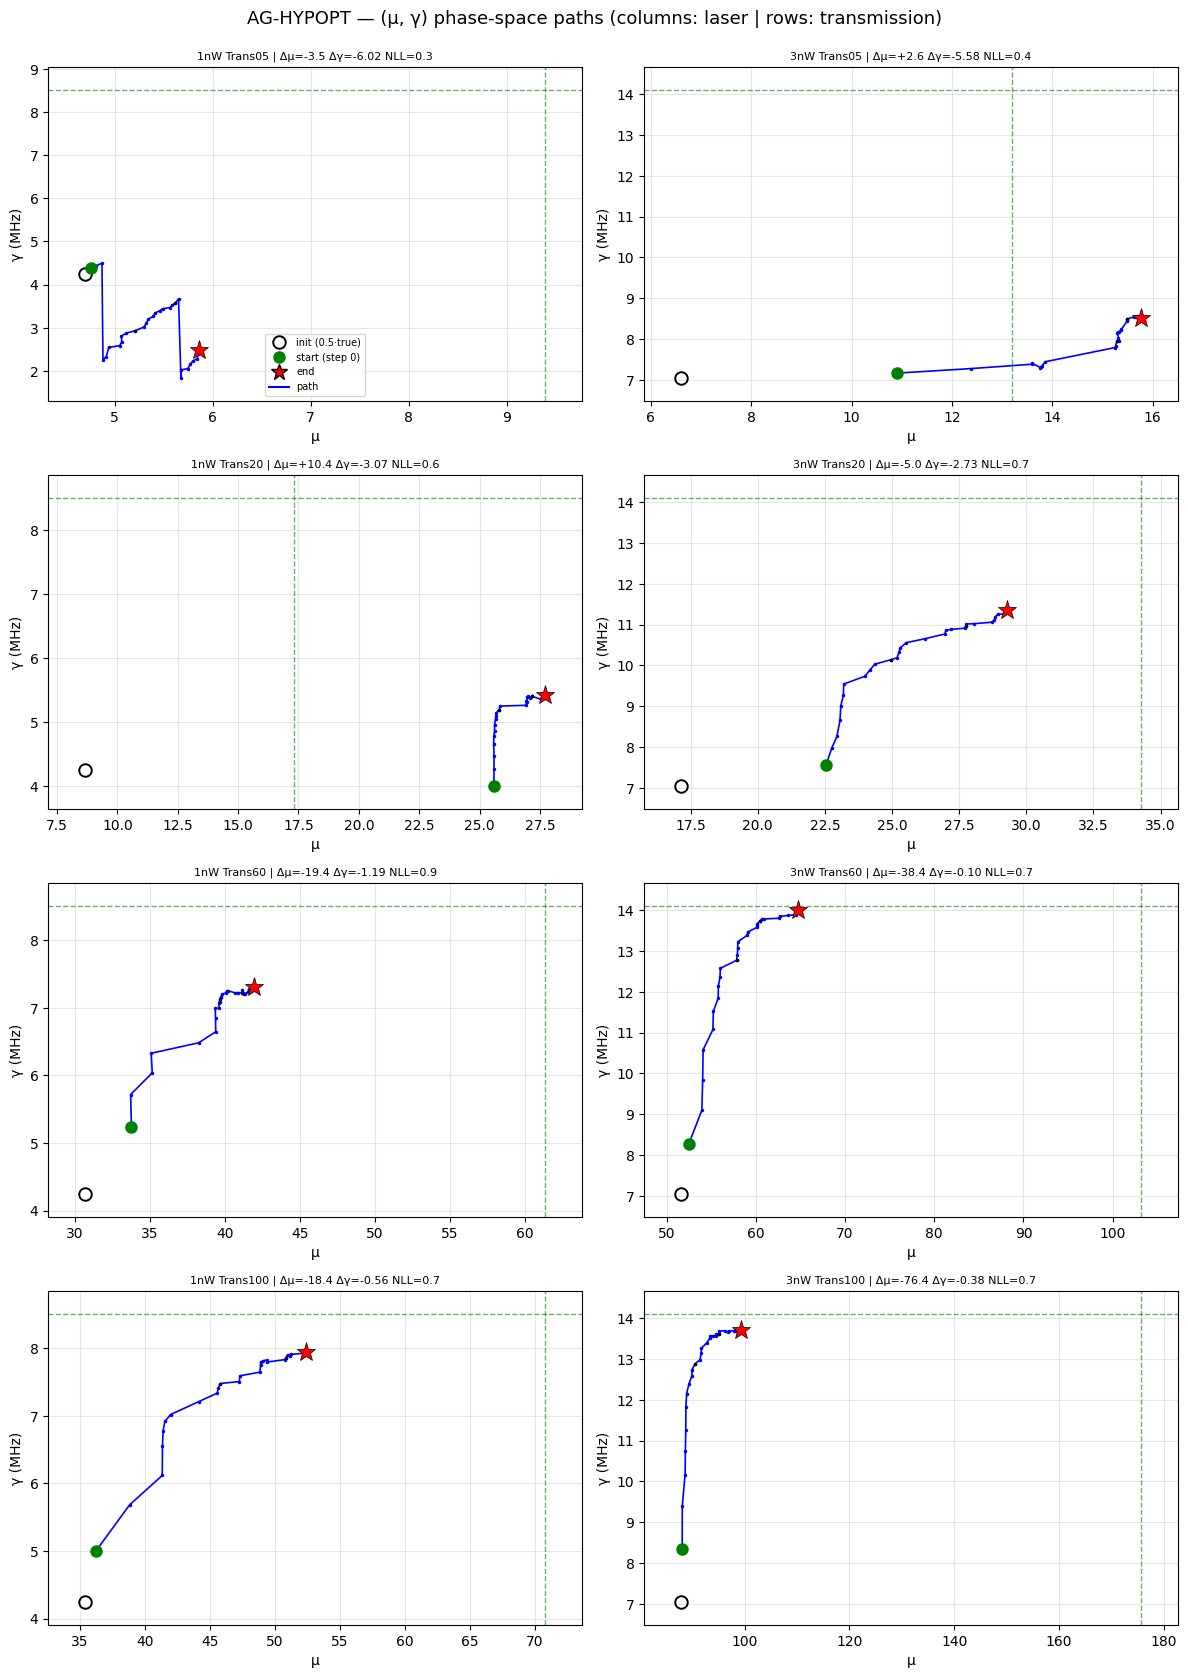

trial finished in 7.8 min
objective = 0.0946 ± 0.0347
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.86   -37.7 |     8.50    2.48   -70.8
1nW Trans20       17.32   27.72   +60.1 |     8.50    5.43   -36.1
1nW Trans60       61.37   41.95   -31.6 |     8.50    7.31   -14.0
1nW Trans100       70.82   52.45   -25.9 |     8.50    7.94    -6.5
3nW Trans05       13.20   15.77   +19.5 |    14.10    8.52   -39.6
3nW Trans20       34.28   29.29   -14.6 |    14.10   11.37   -19.4
3nW Trans60      103.20   64.77   -37.2 |    14.10   14.00    -0.7
3nW Trans100      175.71   99.31   -43.5 |    14.10   13.72    -2.7

weighted objective (T-graded, cap=1.0) = 0.0946 | diverged cells: 0
μ: RMSE 31.976 (rel 36.3%, bias -18.523) | γ: RMSE 3.282 (rel 32.6%, bias -2.454)


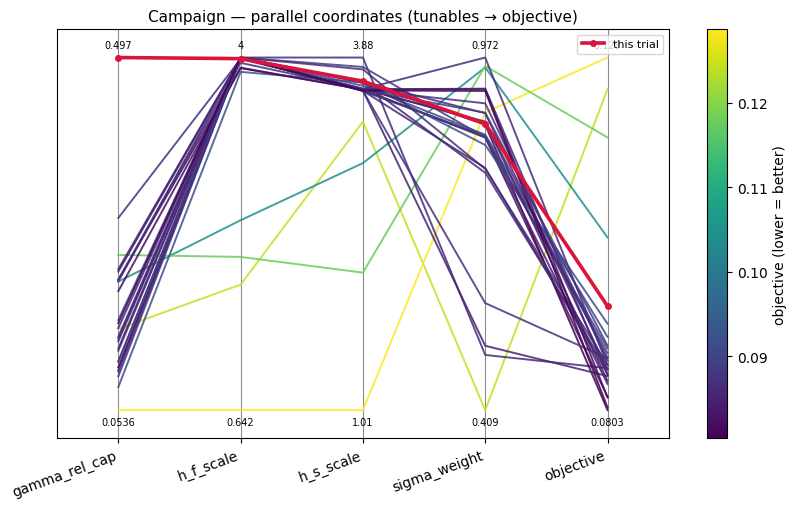

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 27 (sw 0.866, h_f 3.990, h_s 3.683, cap 0.497) ran to completion in 7.8 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0946 +/- 0.0347 - the worst trial so far, worse than trial_07 (0.0803) and slightly worse than trial_10 (0.0922).

mu rel-RMSE 36.3% (slightly worse than trial_07's 35.9%): high-T undershoot (3nW Trans100 -43.5%, 3nW Trans60 -37.2%, 1nW Trans60 -31.6%, 1nW Trans100 -25.9%), low-T overshoot (1nW Trans20 +60.1%, 3nW Trans05 +19.5%); bias -18.52.

gamma rel-RMSE 32.6%, the worst of any trial: the large cap let gamma collapse in the lowest-count cell 1nW Trans05 (-70.8%, gamma_fit 2.48), while the other cells were normal (3nW Trans05 -39.6%, 1nW Trans20 -36.1%, high T near truth).

The candidate had the exact optimal sigma weight (0.866) and near-optimal kernels (h_f 3.990, h_s 3.683) but a very large gamma cap (0.497). At this sigma weight the unbounded gamma step was not tamed, and one low-count cell bottomed out, producing the worst objective. This closes the cap bracket from above: at trial_07's sigma weight the cap must stay small.

**Summary:** Trial 27 (sw=0.866, h_f=3.990, h_s=3.683, cap=0.497) finished in 7.8 min with 0 diverged cells and gamma finite, objective 0.0946 +/- 0.0347 - the worst trial, worse than trial_07 (mu rel-RMSE 36.3%, gamma rel-RMSE 32.6%).
**Key insight:** With the optimal sigma weight and kernels, a very large gamma cap (0.497) let gamma collapse in the lowest-count cell (1nW Trans05 -70.8%), giving the worst objective (0.0946); at this sigma weight the cap must stay small.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 27 (sw=0.866, h_f=3.990, h_s=3.683, cap=0.497): objective 0.0946 +/- 0.0347 - worst trial, worse than trial_07; 0 diverged cells, gamma finite (mu rel-RMSE 36.3%, gamma rel-RMSE 32.6%).'
KEY_INSIGHT = 'With optimal sigma weight and kernels, a very large gamma cap (0.497) let gamma collapse in the lowest-count cell (1nW Trans05 -70.8%), giving the worst objective (0.0946); at this sigma weight the cap must stay small.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_27 | current best: trial_07


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_28.ipynb. Open it and follow its cells from the top.
